In [ ]:
# Libraries
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.io import mmread
import networkx as nx
from scipy.optimize import minimize_scalar

NON RUNNARE (è solo un esempio)

In [ ]:
# Weights: must X_i >= 0 and sum(X) = 1 (X_i in [0,1])
# They are not probabilities in a statistical sense. They measure how much the optimizer believes each vertex belongs to the clique.
# Larger weight: node i is very important
# Smaller weight: node i is probably outside the clique
X = np.random.random(((A2.shape[1], 1)))
X = X/sum(X)
X

array([[0.14140152],
       [0.2880375 ],
       [0.07205449],
       [0.23840999],
       [0.06556629],
       [0.19453021]])

In [ ]:
# We must maximize the function: f(X) = X.T @ A2 @ X
# From theory: if the maximum clique C has size s, the maximum f(X) = 1 - 1/s
# Also: X_i in C = 1/s, 0 otherwise (wiegths corresponding to nodes in the maximum clique will have value 1/s)
f_x = X.T @ A2 @ X # Since A_ij = 1 only if an edge exists, the objective is the weighted sum of all edges.
print('f(x) =', round(float(f_x), 5))
max_f_x = 1 - (1/4)
print('max_f(x) =', max_f_x)

f(x) = 0.6257
max_f(x) = 0.75


Gradient: since differentiating with respect to one coordinate $x_k$ results in $2$ identical sums $\sum_{j}{A_{kj}x_j} + \sum_{i}{A_{ik}x_i}$ and since the graph is undirected ($A=A^T$), the two sums are identical. Therefore, $\frac{\partial f}{\partial x_k}=2\sum_{j}{A_{kj} x_j}$ or, in vector notation, $\nabla f(x)=2Ax$.

In [ ]:
grad = 2 * A2 @ X
print(grad)
i = np.argmax(grad)
s = np.zeros_like(X)
s[i] = 1.0
print(s)

array([[1.57308798],
       [0.94710502],
       [1.4419554 ],
       [0.94710502],
       [1.72475843],
       [1.61093958]])

CODICE

In [ ]:
def plots(experiments, max_clique, alpha=0.15, highlight_best=True, highlight_avg=True):

    fig, axes = plt.subplots(
        nrows=1,
        ncols=4,
        figsize=(25, 5))

    ax1, ax2, ax3, ax4 = axes

    # Find the best experiment

    clique_sizes = [
        exp["Clique"][-1] # List of last clique lengths (at convergence of each experiment)
        for exp in experiments]

    best_clique = np.max(clique_sizes) # Maximum clique size found

    max_clique_idx = [
        i for i, clique in enumerate(clique_sizes) # Indices of experiments that found the maximum clique
        if clique == best_clique]

    best_idx = min(
        max_clique_idx,
        key=lambda i: experiments[i]["Time"][-1]) # Among those, select the one with minimum time

    # General grid

    for ax in axes:
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.5,
            alpha=0.7)

    # Plot all experiments

    for i, exp in enumerate(experiments):

        # Objective vs Iterations
        ax1.plot(
            exp["Objective function"],
            color = 'blue',
            alpha=alpha)

        # Clique vs Iterations
        ax2.plot(
            exp["Clique"],
            color = 'blue',
            alpha=alpha)

        # Objective vs Time
        ax3.plot(
            exp["Time"],
            exp["Objective function"],
            color = 'blue',
            alpha=alpha)

        # Clique vs Time
        ax4.plot(
            exp["Time"],
            exp["Clique"],
            color = 'blue',
            alpha=alpha)

    # Average per iteration

    min_iterations = min(
        len(exp["Objective function"])
        for exp in experiments)

    avg_objective = []
    avg_clique = []
    avg_time = []

    for i in range(min_iterations):
        objective_values = [
            exp["Objective function"][i]
            for exp in experiments
            if i < len(exp["Objective function"])]

        clique_values = [
            exp["Clique"][i]
            for exp in experiments
            if i < len(exp["Clique"])]

        time_values = [
            exp["Time"][i]
            for exp in experiments
            if i < len(exp["Time"])]

        avg_objective.append(np.mean(objective_values))
        avg_clique.append(np.mean(clique_values))
        avg_time.append(np.mean(time_values))

    # Plot averages
    ax1.plot(
        avg_objective,
        linewidth=2,
        color = 'orange',
        label="Average")

    ax2.plot(
        avg_clique,
        linewidth=2,
        color = 'orange',
        label="Average")

    ax3.plot(
        avg_time,
        avg_objective,
        linewidth=2,
        color = 'orange',
        label="Average")

    ax4.plot(
        avg_time,
        avg_clique,
        linewidth=2,
        color = 'orange',
        label="Average")

    # Highlight best experiment

    if highlight_best:

        best = experiments[best_idx]

        ax1.plot(
            best["Objective function"],
            linewidth=2,
            color = 'red',
            label=f"Best run ({best_idx})")

        ax2.plot(
            best["Clique"],
            linewidth=2,
            color = 'red',
            label=f"Best run ({best_idx})")

        ax3.plot(
            best["Time"],
            best["Objective function"],
            linewidth=2,
            color = 'red',
            label=f"Best run ({best_idx})")

        ax4.plot(
            best["Time"],
            best["Clique"],
            linewidth=2,
            color = 'red',
            label=f"Best run ({best_idx})")

    # Maximum clique reference

    ax2.axhline(
        max_clique,
        linestyle="--",
        color="green",
        label=f"Known maximum = {max_clique}")

    ax4.axhline(
        max_clique,
        linestyle="--",
        color="green",
        label=f"Known maximum = {max_clique}")

    # Titles and labels

    ax1.set_title("Objective Function vs Iterations")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Objective")

    ax2.set_title("Clique vs Iterations")
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Clique size")

    ax3.set_title("Objective Function vs Time")
    ax3.set_xlabel("Time (seconds)")
    ax3.set_ylabel("Objective")

    ax4.set_title("Clique vs Time")
    ax4.set_xlabel("Time (seconds)")
    ax4.set_ylabel("Clique size")

    # Y limits for clique plots

    all_cliques = [
        clique
        for exp in experiments
        for clique in exp["Clique"]]

    min_clique = min(all_cliques)

    ax2.set_ylim(
        min_clique - 1,
        max_clique + 5)

    ax4.set_ylim(
        min_clique - 1,
        max_clique + 5)

    ax1.legend()
    ax2.legend()
    ax3.legend()
    ax4.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def results_stats(experiments, name):

    clique_sizes = [exp["Clique"][-1]
                    for exp in experiments]

    time_sizes = [exp["Time"][-1]
                  for exp in experiments]

    max_clique = np.max(clique_sizes)
    max_count = np.sum(clique_sizes == max_clique)
    avg_clique = round(np.mean(clique_sizes),2)
    std_clique = round(np.std(clique_sizes),2)
    avg_time = round(np.mean(time_sizes),2)

    d = {
        'Instances - Algorithm': [name],
        'Max': [f'{max_clique} ({max_count})'], # experiment max clique + (n_times it was reached)
        'Mean': [avg_clique],
        'Std': [std_clique],
        'CPU Time': [avg_time]
        }

    df = pd.DataFrame(data=d)

    return df

In [ ]:
# The greedy verification guarantees that the returned set is actually a clique.
# Assumes that the higher weight is by default part of the clique
def greedy_verification(x, A):
    idx = np.argsort(-x.flatten()) # Array of indexes of sorted weights (greatest to lowest)
    clique = []

    for v in idx:
        ok = True
        # if all(A[v, u] == 1 for u in clique):
            # clique.append(v)
        for u in clique:
            if A[u, v] == 0:
                ok = False
                break

        if ok:
            clique.append(v)

    return len(clique)

In [ ]:
def ex_line_search(x, A, d, reg_method, alpha_2, gamma_max = 1.0):

    if reg_method == '2norm':

        dAd = float(d.T @ A @ d)
        dAx = float(d.T @ A @ x)

        a = dAd + 0.5 * (d.T @ d)
        b = 2.0 * dAx + (d.T @ x)

        if abs(a) < 1e-14:
            gamma = gamma_max if b > 0 else 0.0
        else:
            gamma = -b / (2.0 * a)
            gamma = float(np.clip(gamma, 0.0, gamma_max))

        x_new = x + gamma * d
        f_new = obj_function(x_new, A, reg_method)

        return x_new, f_new

    elif reg_method == 'expreg':

        def objective_gamma(gamma):
            x_gamma = x + gamma * d
            return -(x_gamma.T @ A @ x_gamma + alpha_2 * np.sum(np.exp(-5 * x_gamma) - 1))

        # No close solution for expreg, use numerical method
        result = minimize_scalar(objective_gamma, bounds=(0.0, gamma_max), method='bounded')
        gamma = result.x

        x_new = x + gamma * d
        f_new = obj_function(x_new, A, reg_method, alpha_2)

        return x_new, f_new

    else:

        dAd = float(d.T @ A @ d)
        dAx = float(d.T @ A @ x)

        if abs(dAd) < 1e-14:
            if dAx > 1e-14:
                gamma = gamma_max
            elif dAx < -1e-14:
                gamma = 0.0
            else:
                gamma = 0.0
        else:
            gamma = -dAx / dAd
            gamma = float(np.clip(gamma, 0.0, gamma_max))

        x_new = x + gamma * d
        f_new = obj_function(x_new, A, reg_method)

        return x_new, f_new

In [ ]:
# Armijo rule

def armijo(x, A, d, grad, reg_method, alpha_2,
           alpha = 1.0, delta=0.5, c=1e-4):

    f_x = obj_function(x, A, reg_method, alpha_2)
    directional_derivative = float(grad.T @ d)

    while True:

        x_new = x + alpha * d
        f_new = obj_function(x_new, A, reg_method, alpha_2)

        # Armijo condition for MAXIMIZATION
        if f_new >= (f_x + c * alpha * directional_derivative):
            break

        alpha *= delta

        # Safety
        if alpha < 1e-12:
            print('alpha too small')
            return x.copy(), f_x

    return x_new, f_new

In [ ]:
# Objective function

def obj_function(x, A, reg_method, alpha_2 = 0.04):
    if reg_method == '2norm':
        return float(x.T @ A @ x + 0.5 * (x.T @ x))
    elif reg_method == 'expreg':
        return float(x.T @ A @ x + alpha_2 * np.sum(np.exp(-5 * x) - 1))
    else:
        return float(x.T @ A @ x)

In [ ]:
# LMO

def LMO(x, grad):
    ind = np.argmax(grad)
    s = np.zeros_like(x)
    s[ind] = 1.0
    d = s - x
    fw_gap = float(grad.T @ d) # Frank–Wolfe gap (for stopping condition)

    return d, s, fw_gap

In [ ]:
# Frank-Wolfe algorithm with variants

def frank_wolfe(max_iter=5000,
                        x0 = None,
                        A = None,
                        fw_variant = 'standard', # or awaysteps or pairwise
                        reg_method = None, # Which regularization technique should be applied
                        alpha_2 = 0.04, # alpha parameter of exp regularization (useful only if reg_method = 'expreg')
                        step_strat = None, # Which step strategy method should be applied
                        tol = 1e-4,
                        max_time = 180):

    x = x0.copy()
    n=len(x)
    time_l = []
    n_clique = [greedy_verification(x, A)]

    # Regularization method
    #here we do A@x once

    # what if we remove these 3 if and just do:
    # start_time = time.time()
    # f_history = [obj_function(x, A, reg_method, alpha_2)]
    # time_l.append(time.time() - start_time)

    ## 2 Norm
    if reg_method == '2norm':
        #starting time
        start_time = time.time()
        f_history = [obj_function(x, A, reg_method)]
        time_l.append(time.time() - start_time)

    ## 0 Norm
    elif reg_method == 'expreg':
        start_time = time.time()
        f_history = [obj_function(x, A, reg_method, alpha_2)]
        time_l.append(time.time() - start_time)

    # NO regularization
    elif reg_method == 'noreg':
        start_time = time.time()
        f_history = [obj_function(x, A, reg_method)]
        time_l.append(time.time() - start_time)


    for i in range(max_iter):
        # Gradient
        #here we compute A@x once
        if reg_method == '2norm':
            grad = 2 * A @ x + x
        elif reg_method == 'expreg':
            grad = 2 * A @ x - alpha_2 * 5 * np.exp(-5 * x)
        elif reg_method == 'noreg':
            grad = 2 * A @ x

        # LMO
        #here we compute grad@d once
        d_fw, s, fw_gap = LMO(x, grad)

        # Away direction
        if fw_variant != 'standard':
            support = np.flatnonzero(x.ravel() > 1e-12) # Find active set
            ind_v = support[np.argmin(grad.ravel()[support])]
            v = np.zeros_like(x)
            v[ind_v] = 1.0
            d_A = x - v
            A_gap = float(grad.T @ d_A)

            # Coefficient of the away vertex
            alpha_v = float(x[ind_v])

        #check stop condition
        if (i > 0 and fw_gap < tol):
            print(f'Tolerance of the frank-wolf algorithm was reached at time: {round(time.time() - start_time, 5)}, iter: {i}')
            break

        # Choose direction
        if fw_variant == 'awaysteps':
            if fw_gap >= A_gap:
                d = d_fw
                gamma_max = 1.0
            else:
                d = d_A
                if alpha_v >= 1.0 - 1e-12:
                    gamma_max = 0.0
                else:
                    gamma_max = alpha_v / (1.0 - alpha_v)

        elif fw_variant == 'pairwise':
            d = s - v
            gamma_max = alpha_v

        elif fw_variant == 'standard':
            d = d_fw
            gamma_max = 1.0


        #here we compute A@x once
        if step_strat == 'line_search':
            x_new, f_x = ex_line_search(x, A, d, reg_method, alpha_2, gamma_max)
        elif step_strat == 'armijo':
            # in the armijo function, we can use directly the value at the last position of f_history 
            # that should be f_history[i+1] since we store 1 value before starting the cycle
            x_new, f_x = armijo(x, A, d, grad, reg_method,
                                alpha_2, alpha = gamma_max#, delta=0.5, c=1e-4
                                #f_history[i+1]
                               )
        elif step_strat == 'diminishing':
            gamma = 2.0 / (i + 2.0)
            if gamma > gamma_max:
                gamma = gamma_max
            x_new = x + gamma * d
            f_x = obj_function(x_new, A, reg_method, alpha_2) #this has to be computed again because we just changed x?

        f_history.append(f_x)
        n_clique.append(greedy_verification(x_new, A))
        time_l.append(time.time() - start_time)

        x = x_new

        #check stop condition
        if time.time() - start_time > max_time:
            print(f'Max time of the frank-wolf algorithm reached at: {round(time.time() - start_time, 5)}, iter: {i}')
            break

    if i == max_iter-1:
        print(f"The frank-wolf algorithm didn't reached convergence at time: {round(time.time() - start_time, 5)}, iter: {i}")

    results = {
             #'X' : x,
             #'Local_max' : local_maximum,
             'Time' : time_l,
             'Clique' : n_clique,
             'Objective function' : f_history,
             'Iterations' : i+1
             }

    return results

In [ ]:
# Dowload dataset: brock400-2, C250-9, C1000-9, DSJC1000-5, gen400-p0-9-55, hamming8-4, keller5, p-hat700-3

def adj_matrix(dataset):
    file = 'Data/' + dataset + '.mtx'
    A = mmread(file).astype(np.float64)
    A = A.toarray()
    return A

dataset = 'C250-9'
A = adj_matrix(dataset)

In [ ]:
# Multistart Experiments

def experiments(fw_variant,
                adj_mat,
                n_trials,
                max_iter,
                regularization_method,
                alpha_2,
                step_strategy,
                tolerance = 1e-3,
                max_time = 60,
                set_seed = 123):

    results = []

    rng = np.random.default_rng(set_seed)

    for trial in range(n_trials):
        X = rng.dirichlet(np.ones(adj_mat.shape[0])).reshape(-1, 1)

        fw = frank_wolfe(
                fw_variant = fw_variant,
                max_iter = max_iter,
                x0 = X, A = adj_mat,
                reg_method = regularization_method,
                alpha_2 = alpha_2,
                step_strat = step_strategy,
                tol = tolerance,
                max_time = max_time)

        results.append({
            "trial": trial,
            #"X": fw['X'],
            "Clique": fw['Clique'],
            "Time": fw["Time"],
            "Objective function": fw["Objective function"],
            "Iterations": fw["Iterations"]
        })

    return results

In [ ]:
results = experiments(fw_variant = 'awaysteps',
                      adj_mat = A,
                      n_trials = 100,
                      max_iter = 2000,
                      regularization_method = 'expreg', # noreg, 2norm, expreg
                      alpha_2 = 0.04, # alpha parameter of expreg
                      step_strategy = 'line_search', # diminishing, armijo, line_search
                      tolerance = 1e-3,
                      max_time = 60,
                      set_seed = 123)

/tmp/ipykernel_834/2367554375.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x.T @ A @ x + alpha_2 * np.sum(np.exp(-5 * x) - 1))
/tmp/ipykernel_834/2584629860.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fw_gap = float(grad.T @ d) # Frank–Wolfe gap (for stopping condition)
/tmp/ipykernel_834/1927808660.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A_gap = float(grad.T @ d_A)
/tmp/ipykernel_834/1927808660.py:60: DeprecationWarning: Co

The frank-wolf algorithm didn't reached convergence at time: 3.39588, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.78044, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.81506, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.76065, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.80623, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.76181, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 2.36139, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 2.70112, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.82597, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.85162, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.79348, iter: 1999
The frank-wolf algorithm didn't reached convergence at time: 1.84167, iter: 1999
The frank-wolf algorithm did

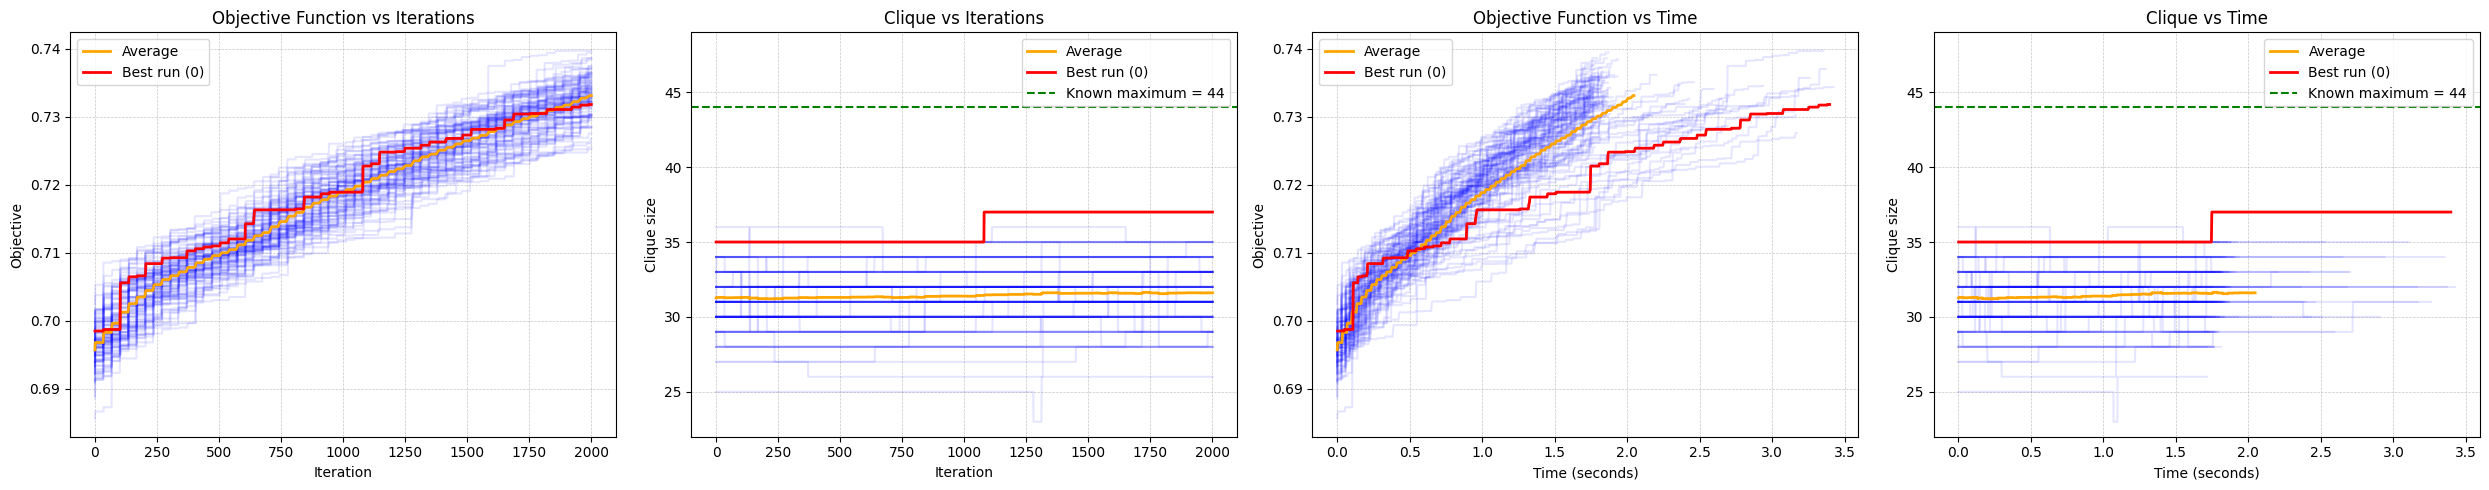

,Instances - Algorithm,Max,Mean,Std,CPU Time
0,C250-9 - fw_2norm_exact_line_search,37 (1),31.61,2.02,2.05


In [ ]:
plots(results, max_clique=44, alpha=0.10)
results_stats(results, name = dataset + ' - fw_2norm_exact_line_search')

In [ ]:
# Adjacency matrix in csv to visualize in Gephi
#pd.DataFrame(A).to_csv(f'Data/{dataset}.csv')